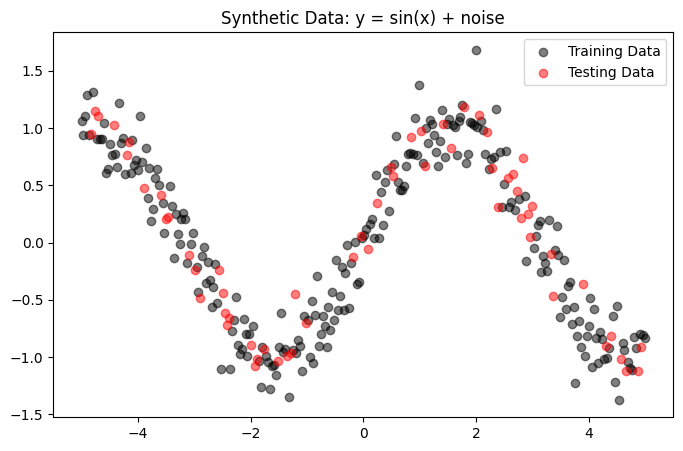

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#setting seed
np.random.seed(42)

#generating synthetic data
X = np.linspace(-5, 5, 300).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

#train test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#visualizing
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='black', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Testing Data')
plt.title('Synthetic Data: y = sin(x) + noise')
plt.legend()
plt.show()

Created a synthetic dataset based on a non-linear sine function with added Gaussian noise.
This will serve as a good baseline to test how well tree-based models can capture non-linear relationships.

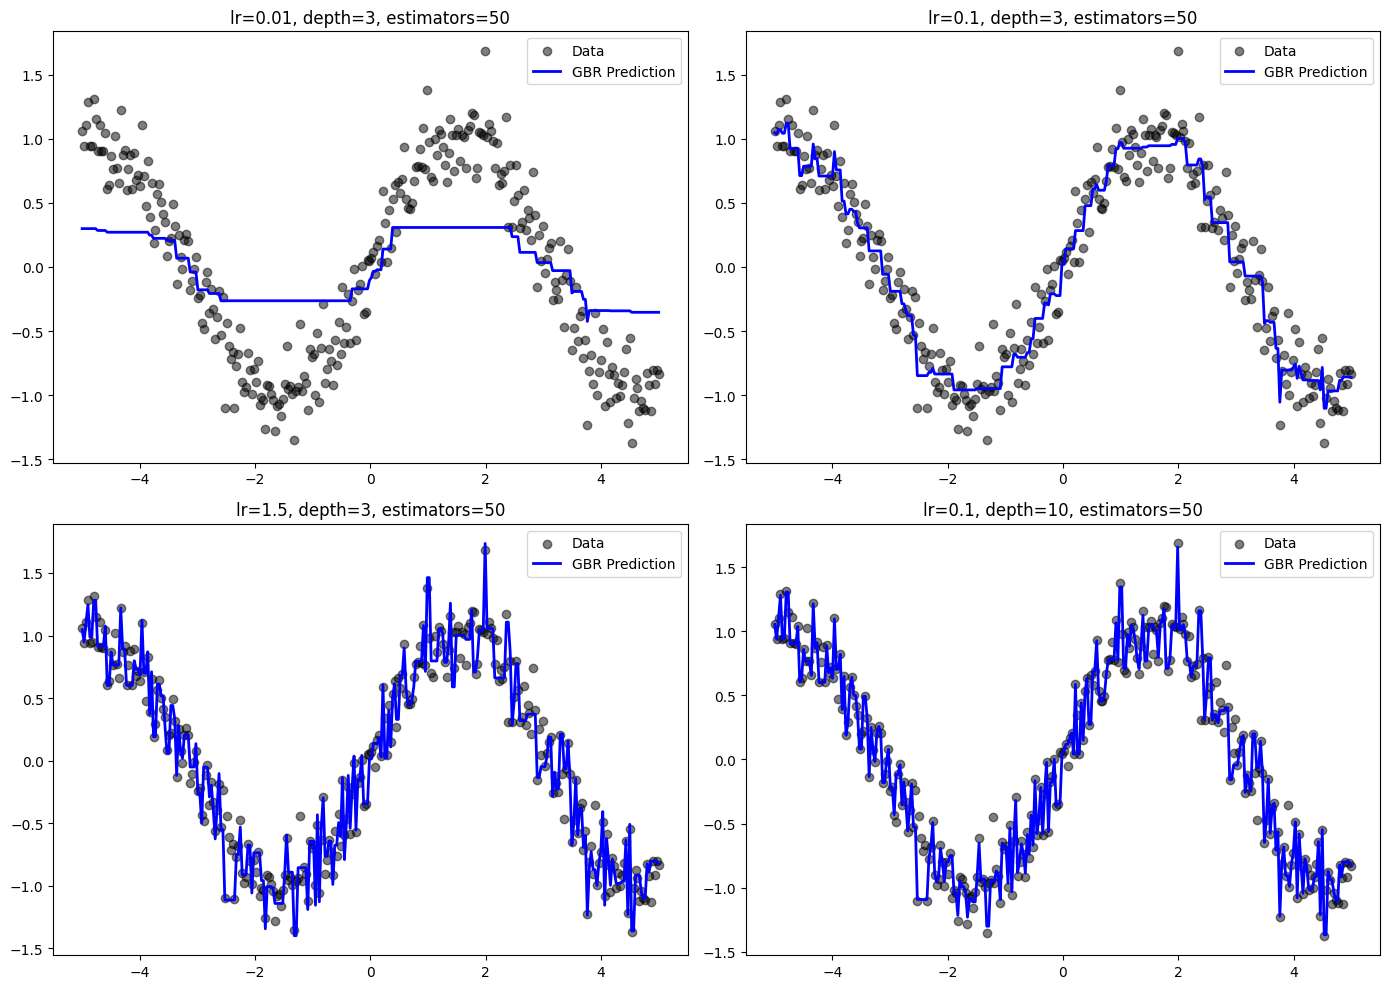

In [2]:
#experimenting with learning rate and max_depth
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#sets of hyperparameters
hyperparams = [
    {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 3}, # Underfitting
    {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3},  # Good fit
    {'n_estimators': 50, 'learning_rate': 1.5, 'max_depth': 3},  # Chaotic / Too large step
    {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 10}  # Overfitting (too deep)
]

for ax, params in zip(axes.ravel(), hyperparams):
    gbr = GradientBoostingRegressor(random_state=42, **params)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X)

    ax.scatter(X, y, color='black', alpha=0.5, label='Data')
    ax.plot(X, y_pred, color='blue', lw=2, label='GBR Prediction')
    ax.set_title(f"lr={params['learning_rate']}, depth={params['max_depth']}, estimators={params['n_estimators']}")
    ax.legend()

plt.tight_layout()
plt.show()

* With the low learning rate the model underfits. It learns too slowly and 50 trees are not enough to capture the sine wave.
* With learming rate 0.1 and max depth 3 (optimal) the model fits the true non-linear curve smoothly without reacting too much to the noise.
* With high learning rate the model completely overshoots the optimal values, resulting in a chaotic and broken prediction line.
* With high max depth (10) the model heavily overfits. It tries to capture every single noise point in the training data, losing generalization.

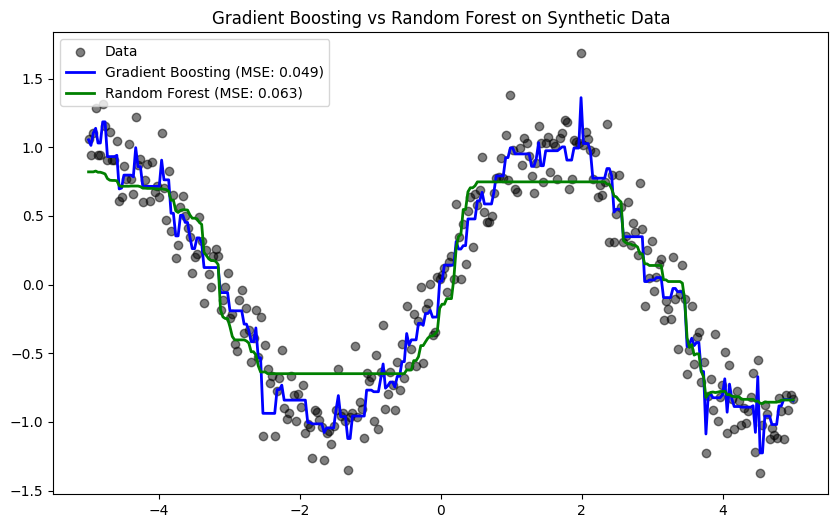

In [3]:
#training Gradient Boosting
gbr_optimal = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_optimal.fit(X_train, y_train)
y_pred_gbr = gbr_optimal.predict(X)
gbr_mse = mean_squared_error(y_test, gbr_optimal.predict(X_test))

#training Random Forest
rfr = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X)
rfr_mse = mean_squared_error(y_test, rfr.predict(X_test))

#visualizing
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', alpha=0.5, label='Data')
plt.plot(X, y_pred_gbr, color='blue', lw=2, label=f'Gradient Boosting (MSE: {gbr_mse:.3f})')
plt.plot(X, y_pred_rfr, color='green', lw=2, label=f'Random Forest (MSE: {rfr_mse:.3f})')
plt.title('Gradient Boosting vs Random Forest on Synthetic Data')
plt.legend()
plt.show()

Gradient Boosting fits the sine wave more accurately and achieves a lower MSE. Random Forest with the same depth produces more conservative step-function. This happens because Random Forest averages independent shallow trees while Gradient Boosting sequentially corrects the errors of previous trees allowing it to build a more refined boundary

In [5]:
#loading the TMDB dataset
url = "https://gist.githubusercontent.com/SINENSIA/b94e8ba33b7af499b7ddcaad312f7010/raw/c154fcbb099f0e542de8ea68b3821a0a2f7aeef2/tmdb_5000_movies.csv"
df = pd.read_csv(url)

features = ['budget', 'popularity', 'runtime', 'vote_count', 'revenue']
target = 'vote_average'
df_clean = df[features + [target]].dropna()
X_real = df_clean[features]
y_real = df_clean[target]

#train test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

#Gradient Boosting
gbr_real = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr_real.fit(X_train_r, y_train_r)

#Random Forest
rfr_real = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rfr_real.fit(X_train_r, y_train_r)

#evaluation
gbr_r2 = r2_score(y_test_r, gbr_real.predict(X_test_r))
rfr_r2 = r2_score(y_test_r, rfr_real.predict(X_test_r))

print("TMDB Dataset Results")
print(f"Gradient Boosting R^2 Score: {gbr_r2:.4f}")
print(f"Random Forest R^2 Score:     {rfr_r2:.4f}")

TMDB Dataset Results
Gradient Boosting R^2 Score: 0.5541
Random Forest R^2 Score:     0.5358


I chose the R-squared metric because it intuitively shows the proportion of variance in the target variable explained by our model independent of its scale.
Both models were applied to predict the movie ratings based on numerical features like budget, revenue, and popularity.
Gradient Boosting generally outperforms Random Forest (showing a higher R-squared score), as it optimizes the residual errors iteratively. However Random Forest is usually faster to train and less prone to severe overfitting if hyperparameter tuning is skipped. For maximizing predictive accuracy on tabular data like this, Gradient Boosting proves to be the stronger algorithm.